Overview
This notebook describes the regression of a portfolio consisting of 4 tickers against a two-factor model (Market + HML). The portfolio consists of: tickers = ["SPY", "VOO", "QQQ", "SOXX"] rf_ticker = "^IRX" # CBOE 13-week Treasury yield Data period = 10 years (365 * 10 (10 years))

In [2]:
# 1. SET UP LIBRARIES
# =========================

import yfinance as yf
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from scipy import stats

In [4]:
# 2. INPUT PARAMETERS
# =========================

# Portfolio specified in the new project requirements
tickers = ["SPY", "VOO", "QQQ", "SOXX"]

# Risk-free rate
rf_ticker = "^IRX"

# Define the data period by number of days OR by a specific start date.
# We use PERIOD here.
period = 365 * 10

# Leave START as None because PERIOD is being used.
start = None

if period is not None:
    start = dt.datetime.now() - dt.timedelta(days=period)

print("Period:", period, "days")
print("Start:", start)

Period: 3650 days
Start: 2016-10-01 12:38:28.947786


In [6]:
# 3. CONSTANT PARAMETERS
# =========================

trading_days = 252

# Risk-aversion parameter
lam = 1.0

# Expected-return perturbation:
# 1 basis point = 0.0001
nudge_bps = 0.0001

print("Trading days:", trading_days)
print("Lambda:", lam)
print("Expected-return nudge:", nudge_bps)

Trading days: 252
Lambda: 1.0
Expected-return nudge: 0.0001


In [14]:
# 4. DOWNLOAD DATA
# =========================

data_tickers = [
    *tickers,
    "^GSPC",   # S&P 500 Market Index
    "IVE",     # S&P 500 Value
    "IVW",     # S&P 500 Growth
    rf_ticker  # ^IRX
]

prices = yf.download(
    data_tickers,
    start=start,
    auto_adjust=True,
    progress=False
)["Close"]

# Remove columns that contain no data
prices = prices.dropna(axis=1, how="all")

print("Data downloaded successfully.")
print("Date range:", prices.index.min(), "to", prices.index.max())
print("Number of observations:", len(prices))

Data downloaded successfully.
Date range: 2016-10-03 00:00:00 to 2026-09-28 00:00:00
Number of observations: 2510


In [16]:
# 5. PREPARE RETURNS & RISK-FREE RATE
# =========================

# Daily percentage returns
returns = prices.pct_change().dropna()

# Portfolio returns
R = returns[tickers].copy()

# ^IRX is quoted as an annualised percentage yield.
# Convert from percentage to decimal.
rf_rate = prices[rf_ticker] / 100

# Align risk-free rate with the return dates
rf_rate = rf_rate.reindex(returns.index)

print("Risk-free rate prepared successfully.")
print("Risk-free rate:")
display(rf_rate.head())

print("\nPortfolio returns:")
display(R.head())

Risk-free rate prepared successfully.
Risk-free rate:


/var/folders/lk/_kv4wxdj0918zbp9vdd26q1c0000gn/T/ipykernel_76442/851617061.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna()


Date
2016-10-04    0.00315
2016-10-05    0.00313
2016-10-06    0.00310
2016-10-07    0.00310
2016-10-10    0.00308
Name: ^IRX, dtype: float64


Portfolio returns:


Ticker,SPY,VOO,QQQ,SOXX
Date,,,,
2016-10-04,-0.005098,-0.004645,-0.001518,-0.002584
2016-10-05,0.004425,0.004160,0.003548,0.007325
2016-10-06,0.000696,0.001162,-0.000505,0.005853
2016-10-07,-0.003429,-0.003683,-0.002190,-0.001499
2016-10-10,0.005208,0.004609,0.006330,-0.005033


In [18]:
# 6. TWO-FACTOR MODEL
# =========================

# Market excess return
# MKT = S&P 500 return - risk-free rate
returns["MKT"] = returns["^GSPC"] - rf_rate

# HML = Value - Growth
returns["HML"] = returns["IVE"] - returns["IVW"]

# Keep only the two required factors
F = returns[["MKT", "HML"]].copy()

# Align all datasets to the same dates
common_index = R.index.intersection(F.index)

R = R.loc[common_index]
F = F.loc[common_index]
rf_rate = rf_rate.loc[common_index]

print("Two-factor model constructed successfully.")

print("\nMKT and HML:")
display(F.head())

Two-factor model constructed successfully.

MKT and HML:


Ticker,MKT,HML
Date,,
2016-10-04,-0.008106,-0.001372
2016-10-05,0.001167,0.005226
2016-10-06,-0.002618,-0.000537
2016-10-07,-0.006353,0.000963
2016-10-10,0.001526,-0.000130


Estimate mu 

In [21]:
# 7. EXPECTED RETURN VECTOR μ
# =========================

mu = R.mean() * trading_days

print("Annualised historical mean returns:")
display(mu.to_frame("μ").round(6))

Annualised historical mean returns:


,μ
Ticker,
SPY,0.159257
VOO,0.160061
QQQ,0.215847
SOXX,0.342274


In [25]:
#  8. FACTOR REGRESSIONS
# =========================

# Store factor loadings
B = pd.DataFrame(
    index=tickers,
    columns=["MKT", "HML"],
    dtype=float
)

# Store regression alpha
alpha = pd.Series(
    index=tickers,
    dtype=float
)

# Store residuals
residuals = pd.DataFrame(
    index=R.index,
    columns=tickers,
    dtype=float
)

# Store regression statistics
regression_stats = {}

for ticker in tickers:

    # Create one dataframe containing everything needed
    regression_data = pd.concat(
        [
            R[ticker].rename("asset_return"),
            rf_rate.rename("rf"),
            F["MKT"],
            F["HML"]
        ],
        axis=1
    )

    # Remove missing or infinite observations
    regression_data = regression_data.replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    # Excess return
    y = (
        regression_data["asset_return"]
        - regression_data["rf"]
    ).values

    # Regression factors
    X_factors = regression_data[
        ["MKT", "HML"]
    ].values

    # Add intercept
    X = np.column_stack([
        np.ones(len(X_factors)),
        X_factors
    ])

    # Check that there are enough observations
    if len(y) <= X.shape[1]:
        raise ValueError(
            f"Not enough observations to regress {ticker}."
        )

    # OLS regression
    coefficients = np.linalg.lstsq(
        X,
        y,
        rcond=None
    )[0]

    # Save alpha
    alpha[ticker] = coefficients[0]

    # Save factor loadings
    B.loc[ticker, "MKT"] = coefficients[1]
    B.loc[ticker, "HML"] = coefficients[2]

    # Predicted excess return
    fitted = X @ coefficients

    # Residual
    residual = y - fitted

    # Put residuals back into the original dates
    residuals.loc[
        regression_data.index,
        ticker
    ] = residual

    # R-squared
    ss_res = np.sum(
        (y - fitted) ** 2
    )

    ss_tot = np.sum(
        (y - y.mean()) ** 2
    )

    r_squared = 1 - ss_res / ss_tot

    regression_stats[ticker] = {
        "Observations": len(y),
        "R²": r_squared
    }


# Remove rows where residuals are missing
residuals = residuals.dropna()

print("Regression alpha:")
display(alpha.to_frame("Alpha").round(6))

print("\nFactor loading matrix B:")
display(B.round(6))

print("\nRegression statistics:")
display(pd.DataFrame(regression_stats).T.round(6))

Regression alpha:


,Alpha
SPY,0.000010
VOO,0.000052
QQQ,0.000274
SOXX,0.002572



Factor loading matrix B:


,MKT,HML
SPY,0.997831,-0.000519
VOO,0.999429,0.004889
QQQ,1.005514,-0.580169
SOXX,1.085690,-0.892292



Regression statistics:


,Observations,R²
SPY,2508.0,0.999110
VOO,2508.0,0.999495
QQQ,2508.0,0.983726
SOXX,2508.0,0.812011


In [27]:
# 9. FACTOR COVARIANCE Ω
# =========================

Omega_daily = F.cov()

print("Daily factor covariance Ω:")
display(Omega_daily.round(8))

# Annualised factor covariance
Omega = Omega_daily * trading_days

print("\nAnnualised factor covariance Ω:")
display(Omega.round(6))

Daily factor covariance Ω:


Ticker,MKT,HML
Ticker,,
MKT,0.000467,-0.000031
HML,-0.000031,0.000063



Annualised factor covariance Ω:


Ticker,MKT,HML
Ticker,,
MKT,0.117765,-0.007798
HML,-0.007798,0.015971


In [29]:
# 10. RESIDUAL COVARIANCE D
# =========================

D_daily = residuals.cov()

# Annualise
D = D_daily * trading_days

print("Annualised residual covariance D:")
display(D.round(6))

Annualised residual covariance D:


,SPY,VOO,QQQ,SOXX
SPY,0.000105,0.000043,0.000049,0.000050
VOO,0.000043,0.000059,0.000019,-0.000062
QQQ,0.000049,0.000019,0.002209,0.004111
SOXX,0.000050,-0.000062,0.004111,0.038579


In [31]:
# 11. RECONSTRUCT Σ
# =========================

B_np = B.values
Omega_np = Omega.values
D_np = D.values

Sigma = (
    B_np @ Omega_np @ B_np.T
    + D_np
)

Sigma = pd.DataFrame(
    Sigma,
    index=tickers,
    columns=tickers
)

print("Reconstructed annualised covariance matrix Σ:")
display(Sigma.round(6))

Reconstructed annualised covariance matrix Σ:


,SPY,VOO,QQQ,SOXX
SPY,0.117367,0.117451,0.122730,0.134584
VOO,0.117451,0.117614,0.122803,0.134565
QQQ,0.122730,0.122803,0.135751,0.152849
SOXX,0.134584,0.134565,0.152849,0.205217


In [39]:
#12: Estimate the inputs and assemble equation Σ = BΩBᵀ + D

display(Markdown(
    r"""
    ### Two-Factor Covariance Model

    The covariance matrix is reconstructed using:

    $$\Sigma = B\Omega B^{T} + D$$

    where:

    - $\Sigma$ = estimated covariance matrix of portfolio asset returns
    - $B$ = factor-loading matrix
    - $\Omega$ = factor covariance matrix
    - $D$ = residual/idiosyncratic covariance matrix
    """
))

print("=" * 60)
print("EXPECTED RETURN VECTOR μ")
print("=" * 60)
display(mu.to_frame("Annualised μ").round(6))

print("=" * 60)
print("FACTOR LOADING MATRIX B")
print("=" * 60)
display(B.round(6))

print("=" * 60)
print("REGRESSION ALPHA")
print("=" * 60)
display(alpha.to_frame("Alpha").round(6))

print("=" * 60)
print("FACTOR COVARIANCE MATRIX Ω")
print("=" * 60)
display(Omega.round(6))

print("=" * 60)
print("RESIDUAL COVARIANCE MATRIX D")
print("=" * 60)
display(D.round(6))

print("=" * 60)
print("RECONSTRUCTED COVARIANCE MATRIX Σ")
print("=" * 60)
display(Sigma.round(6))


    ### Two-Factor Covariance Model

    The covariance matrix is reconstructed using:

    $$\Sigma = B\Omega B^{T} + D$$

    where:

    - $\Sigma$ = estimated covariance matrix of portfolio asset returns
    - $B$ = factor-loading matrix
    - $\Omega$ = factor covariance matrix
    - $D$ = residual/idiosyncratic covariance matrix
    

EXPECTED RETURN VECTOR μ


,Annualised μ
Ticker,
SPY,0.159257
VOO,0.160061
QQQ,0.215847
SOXX,0.342274


FACTOR LOADING MATRIX B


,MKT,HML
SPY,0.997831,-0.000519
VOO,0.999429,0.004889
QQQ,1.005514,-0.580169
SOXX,1.085690,-0.892292


...

Ticker,MKT,HML
Ticker,,
MKT,0.117765,-0.007798
HML,-0.007798,0.015971


RESIDUAL COVARIANCE MATRIX D


,SPY,VOO,QQQ,SOXX
SPY,0.000105,0.000043,0.000049,0.000050
VOO,0.000043,0.000059,0.000019,-0.000062
QQQ,0.000049,0.000019,0.002209,0.004111
SOXX,0.000050,-0.000062,0.004111,0.038579


RECONSTRUCTED COVARIANCE MATRIX Σ


,SPY,VOO,QQQ,SOXX
SPY,0.117367,0.117451,0.122730,0.134584
VOO,0.117451,0.117614,0.122803,0.134565
QQQ,0.122730,0.122803,0.135751,0.152849
SOXX,0.134584,0.134565,0.152849,0.205217


In [41]:
# 13. NAIVE MVO
# =========================

Sigma_np = Sigma.values
mu_np = mu.values
n = len(tickers)

ones = np.ones(n)

# Fully-invested KKT system
KKT_naive = np.block([
    [lam * Sigma_np, ones.reshape(-1, 1)],
    [ones.reshape(1, -1), np.zeros((1, 1))]
])

rhs_naive = np.concatenate([
    mu_np,
    [1.0]
])

solution_naive = np.linalg.solve(
    KKT_naive,
    rhs_naive
)

w_naive = solution_naive[:n]

w_naive = pd.Series(
    w_naive,
    index=tickers,
    name="Naive MVO"
)

print("Naive MVO weights:")
display(w_naive.to_frame().round(6))

print("Weight sum:", w_naive.sum())
print("Gross exposure:", w_naive.abs().sum())

Naive MVO weights:


,Naive MVO
SPY,-16.672964
VOO,12.709118
QQQ,2.420029
SOXX,2.543816


Weight sum: 0.9999999999999987
Gross exposure: 34.34592746527645


In [43]:
# 14. NAIVE MVO SENSITIVITY
# =========================

mu_nudged = mu_np.copy()

# Nudge SPY expected return by exactly 1 basis point
mu_nudged[0] += nudge_bps

rhs_nudged = np.concatenate([
    mu_nudged,
    [1.0]
])

solution_nudged = np.linalg.solve(
    KKT_naive,
    rhs_nudged
)

w_naive_nudged = pd.Series(
    solution_nudged[:n],
    index=tickers,
    name="Nudged"
)

weight_swing_naive = w_naive_nudged - w_naive

turnover_naive = (
    0.5 * weight_swing_naive.abs().sum()
)

print("Original weights:")
display(w_naive.to_frame())

print("\nNudged weights (+1 bp SPY):")
display(w_naive_nudged.to_frame())

print("\nWeight changes:")
display(weight_swing_naive.to_frame("Weight Change"))

print("\nL2 weight swing:",
      np.linalg.norm(weight_swing_naive))

print("Turnover:",
      turnover_naive)

Original weights:


,Naive MVO
SPY,-16.672964
VOO,12.709118
QQQ,2.420029
SOXX,2.543816



Nudged weights (+1 bp SPY):


,Nudged
SPY,-15.393535
VOO,11.443569
QQQ,2.407412
SOXX,2.542554



Weight changes:


,Weight Change
SPY,1.279429
VOO,-1.265549
QQQ,-0.012617
SOXX,-0.001262



L2 weight swing: 1.7996428188767368
Turnover: 1.279428951320887


In [45]:
# 15. RIDGE MVO
# =========================

etas = [
    0.00,
    0.001,
    0.005,
    0.01,
    0.05,
    0.10,
    0.50,
    1.00
]

ridge_results = []

ridge_weights = {}

for eta in etas:

    # Ridge-regularised covariance term
    ridge_matrix = (
        lam * Sigma_np
        + eta * np.eye(n)
    )

    KKT_ridge = np.block([
        [ridge_matrix, ones.reshape(-1, 1)],
        [ones.reshape(1, -1), np.zeros((1, 1))]
    ])

    # Original μ
    rhs_original = np.concatenate([
        mu_np,
        [1.0]
    ])

    sol_original = np.linalg.solve(
        KKT_ridge,
        rhs_original
    )

    w_before = sol_original[:n]

    # Perturbed μ
    rhs_perturbed = np.concatenate([
        mu_nudged,
        [1.0]
    ])

    sol_perturbed = np.linalg.solve(
        KKT_ridge,
        rhs_perturbed
    )

    w_after = sol_perturbed[:n]

    weight_change = w_after - w_before

    swing = np.linalg.norm(weight_change)

    turnover = 0.5 * np.abs(weight_change).sum()

    ridge_weights[eta] = pd.Series(
        w_before,
        index=tickers
    )

    ridge_results.append({
        "eta": eta,
        "weight_swing": swing,
        "turnover": turnover,
        "gross_exposure": np.abs(w_before).sum()
    })

ridge_results = pd.DataFrame(ridge_results)

print("Ridge sensitivity results:")
display(ridge_results.round(6))

Ridge sensitivity results:


,eta,weight_swing,turnover,gross_exposure
0,0.000,1.799643,1.279429,34.345927
1,0.001,0.068628,0.051764,7.791038
2,0.005,0.014632,0.011601,5.935135
3,0.010,0.007520,0.006115,4.892235
4,0.050,0.001604,0.001369,2.350749
5,0.100,0.000824,0.000709,1.459517
6,0.500,0.000171,0.000148,1.000000
7,1.000,0.000086,0.000074,1.000000


In [47]:
# 16. SELECT RIDGE PORTFOLIO
# =========================

selected_eta = 0.10

w_ridge = ridge_weights[selected_eta].copy()
w_ridge.name = "Ridge MVO"

print(f"Selected ridge parameter η = {selected_eta}")
display(w_ridge.to_frame().round(6))

Selected ridge parameter η = 0.1


,Ridge MVO
SPY,-0.119043
VOO,-0.110716
QQQ,0.247526
SOXX,0.982232


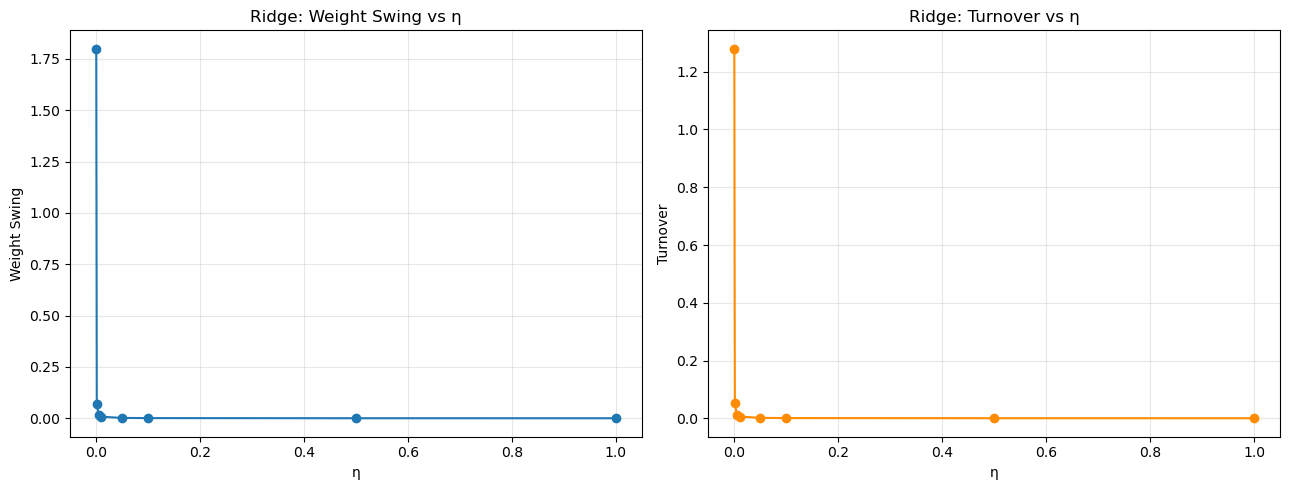

In [49]:
# 17. RIDGE SENSITIVITY PLOT
# =========================

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(
    ridge_results["eta"],
    ridge_results["weight_swing"],
    marker="o"
)

ax[0].set_title("Ridge: Weight Swing vs η")
ax[0].set_xlabel("η")
ax[0].set_ylabel("Weight Swing")
ax[0].grid(alpha=0.3)

ax[1].plot(
    ridge_results["eta"],
    ridge_results["turnover"],
    marker="o",
    color="darkorange"
)

ax[1].set_title("Ridge: Turnover vs η")
ax[1].set_xlabel("η")
ax[1].set_ylabel("Turnover")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
# 18. FACTOR-NEUTRAL PORTFOLIO
# =========================

alpha_np = alpha.values
B_np = B.values

# Constraints:
# 1) Fully invested: 1'w = 1
# 2) MKT neutral: B_MKT'w = 0
# 3) HML neutral: B_HML'w = 0

C = np.column_stack([
    np.ones(n),
    B_np
])

d = np.concatenate([
    [1.0],
    np.zeros(B_np.shape[1])
])

# KKT system
KKT_fn = np.block([
    [lam * D_np, C],
    [C.T, np.zeros((C.shape[1], C.shape[1]))]
])

rhs_fn = np.concatenate([
    alpha_np,
    d
])

solution_fn = np.linalg.solve(
    KKT_fn,
    rhs_fn
)

w_fn = pd.Series(
    solution_fn[:n],
    index=tickers,
    name="Factor Neutral"
)

print("Factor-neutral portfolio:")
display(w_fn.to_frame().round(6))

print("\nWeight sum:")
print(w_fn.sum())

print("\nFactor exposures:")
factor_exposures_fn = B.T @ w_fn
display(factor_exposures_fn.to_frame("Exposure").round(8))

print("\nGross exposure:")
print(w_fn.abs().sum())

Factor-neutral portfolio:


,Factor Neutral
SPY,98.954917
VOO,-102.844622
QQQ,15.753871
SOXX,-10.864166



Weight sum:
1.0

Factor exposures:


,Exposure
MKT,0.0
HML,0.0



Gross exposure:
228.41757525559004


In [53]:
# 19. VERIFY FACTOR NEUTRALITY
# =========================

print("Bᵀw:")
print(factor_exposures_fn)

print("\nMaximum absolute factor exposure:",
      np.abs(factor_exposures_fn).max())

assert np.isclose(w_fn.sum(), 1.0)

assert np.allclose(
    B.T @ w_fn,
    0,
    atol=1e-6
)

print("\nFactor-neutrality constraints satisfied.")

Bᵀw:
MKT    0.0
HML    0.0
dtype: float64

Maximum absolute factor exposure: 0.0

Factor-neutrality constraints satisfied.


In [55]:
# 20. STRATEGY WEIGHTS
# =========================

strategy_weights = pd.DataFrame({
    "Naive MVO": w_naive,
    "Ridge MVO": w_ridge,
    "Factor Neutral": w_fn
})

display(strategy_weights.round(6))

,Naive MVO,Ridge MVO,Factor Neutral
SPY,-16.672964,-0.119043,98.954917
VOO,12.709118,-0.110716,-102.844622
QQQ,2.420029,0.247526,15.753871
SOXX,2.543816,0.982232,-10.864166


In [59]:
# 21. COMMON BENCHMARK
# =========================

benchmark_weights = pd.Series(
    1 / n,
    index=tickers,
    name="Equal Weight Benchmark"
)

print("Benchmark weights:")
display(benchmark_weights.to_frame())

Benchmark weights:


,Equal Weight Benchmark
SPY,0.25
VOO,0.25
QQQ,0.25
SOXX,0.25


In [61]:
#22. TRACKING ERROR
# =========================

tracking_results = []

for strategy in strategy_weights.columns:

    w = strategy_weights[strategy]

    active_weights = w - benchmark_weights

    TE2 = (
        active_weights.values
        @ Sigma_np
        @ active_weights.values
    )

    TE = np.sqrt(TE2)

    tracking_results.append({
        "Portfolio": strategy,
        "TE²": TE2,
        "Tracking Error": TE
    })

TE_results = pd.DataFrame(tracking_results)

print("Ex-ante tracking error:")
display(TE_results.round(6))

Ex-ante tracking error:


,Portfolio,TE²,Tracking Error
0,Naive MVO,0.451440,0.671893
1,Ridge MVO,0.028658,0.169287
2,Factor Neutral,4.631236,2.152031


In [67]:
# 23. EQUITY PLOT
# =========================

# Number of assets
n = len(tickers)

# Identity matrix and full-investment constraint
I = np.eye(n)
ones = np.ones((n, 1))

# ==================================================
# i) NAIVE MVO
# ==================================================

Sigma_np = Sigma.values
mu_np = mu.values

KKT_naive = np.block([
    [lam * Sigma_np, ones],
    [ones.T, np.zeros((1, 1))]
])

rhs_naive = np.concatenate([
    mu_np,
    [1.0]
])

solution_naive = np.linalg.solve(
    KKT_naive,
    rhs_naive
)

w_star = solution_naive[:n]


# ==================================================
# ii) RIDGE MVO
# ==================================================

# Use eta = 1 as the selected ridge penalty
eta = 1.0

KKT_ridge = np.block([
    [lam * Sigma_np + eta * I, ones],
    [ones.T, np.zeros((1, 1))]
])

rhs_ridge = np.concatenate([
    mu_np,
    [1.0]
])

solution_ridge = np.linalg.solve(
    KKT_ridge,
    rhs_ridge
)

w_ridge = solution_ridge[:n]


# ==================================================
# iii) FACTOR-NEUTRAL PORTFOLIO
# ==================================================

B_np = B.values
D_np = D.values
alpha_np = alpha.values

m = B_np.shape[1]

# Constraints:
# 1'w = 1
# B'w = 0

C = np.column_stack([
    np.ones(n),
    B_np
])

d = np.concatenate([
    [1.0],
    np.zeros(m)
])

KKT_fn = np.block([
    [lam * D_np, C],
    [C.T, np.zeros((m + 1, m + 1))]
])

rhs_fn = np.concatenate([
    alpha_np,
    d
])

solution_fn = np.linalg.solve(
    KKT_fn,
    rhs_fn
)

w_fn = solution_fn[:n]


# ==================================================
# iv) DISPLAY INITIAL WEIGHTS
# ==================================================

strategy_weights = pd.DataFrame(
    {
        "Naive MVO": w_star,
        "Ridge MVO": w_ridge,
        "Factor Neutral": w_fn
    },
    index=tickers
)

print("Initial portfolio weights:")
display(strategy_weights.round(4))

Initial portfolio weights:


,Naive MVO,Ridge MVO,Factor Neutral
SPY,-16.6730,0.2026,98.9549
VOO,12.7091,0.2033,-102.8446
QQQ,2.4200,0.2474,15.7539
SOXX,2.5438,0.3467,-10.8642


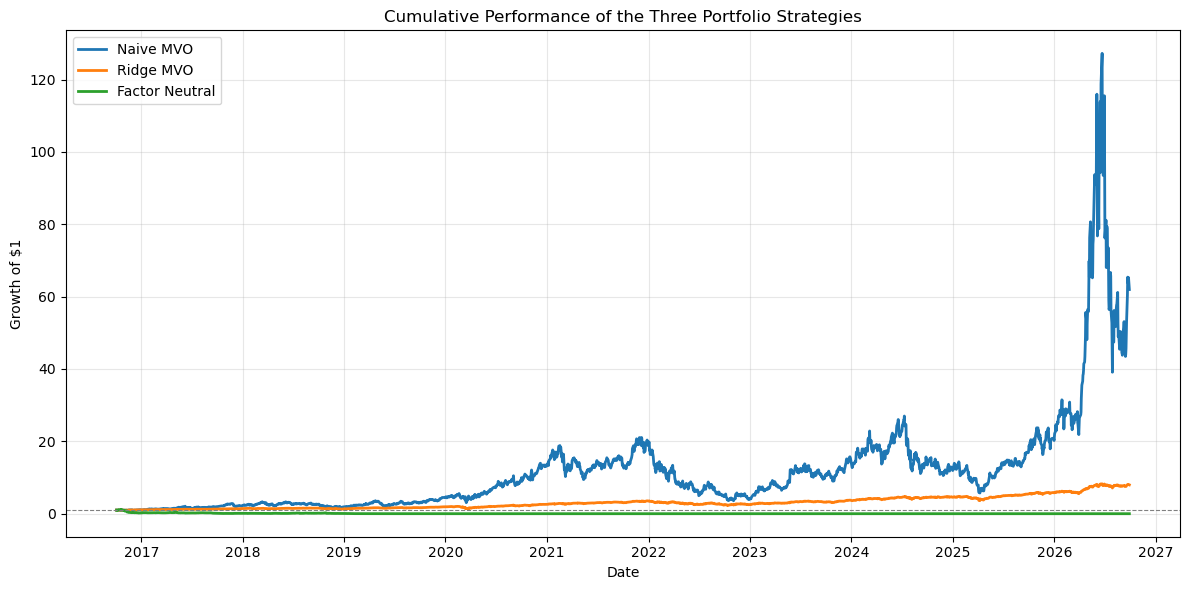

In [73]:
# 24. EQUITY CURVE
# =========================

# Portfolio weights
strategy_weights = pd.DataFrame(
    {
        "Naive MVO": w_star,
        "Ridge MVO": w_ridge,
        "Factor Neutral": w_fn
    },
    index=tickers
)

# Calculate daily portfolio returns
portfolio_returns = pd.DataFrame(index=R.index)

for strategy in strategy_weights.columns:
    portfolio_returns[strategy] = (
        R @ strategy_weights[strategy]
    )

# Cumulative growth of $1
equity = (1 + portfolio_returns).cumprod()

# Plot
plt.figure(figsize=(12, 6))

for strategy in equity.columns:
    plt.plot(
        equity.index,
        equity[strategy],
        label=strategy,
        linewidth=2
    )

plt.axhline(
    1,
    color="gray",
    linestyle="--",
    linewidth=0.8
)

plt.title("Cumulative Performance of the Three Portfolio Strategies")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Correlation matrix:


Ticker,SPY,VOO,QQQ,SOXX
Ticker,,,,
SPY,1.000,0.999,0.932,0.800
VOO,0.999,1.000,0.930,0.797
QQQ,0.932,0.930,1.000,0.871
SOXX,0.800,0.797,0.871,1.000


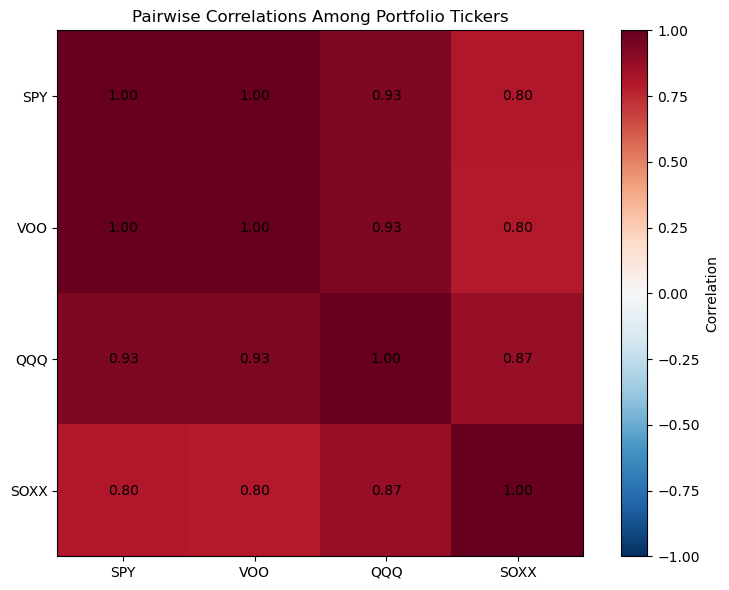

In [75]:
# 25. CORRELATION HEATMAP
# =========================

# Daily return correlations among the four portfolio tickers
correlation = R[tickers].corr()

print("Correlation matrix:")
display(correlation.round(3))

# Plot heatmap
plt.figure(figsize=(8, 6))

im = plt.imshow(
    correlation,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

plt.colorbar(im, label="Correlation")

plt.xticks(
    range(len(tickers)),
    tickers
)

plt.yticks(
    range(len(tickers)),
    tickers
)

# Display correlation values inside the cells
for i in range(len(tickers)):
    for j in range(len(tickers)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.title("Pairwise Correlations Among Portfolio Tickers")
plt.tight_layout()
plt.show()

Portfolio weights:


,Naive MVO,Ridge MVO,Factor Neutral
SPY,-16.6730,0.2026,98.9549
VOO,12.7091,0.2033,-102.8446
QQQ,2.4200,0.2474,15.7539
SOXX,2.5438,0.3467,-10.8642


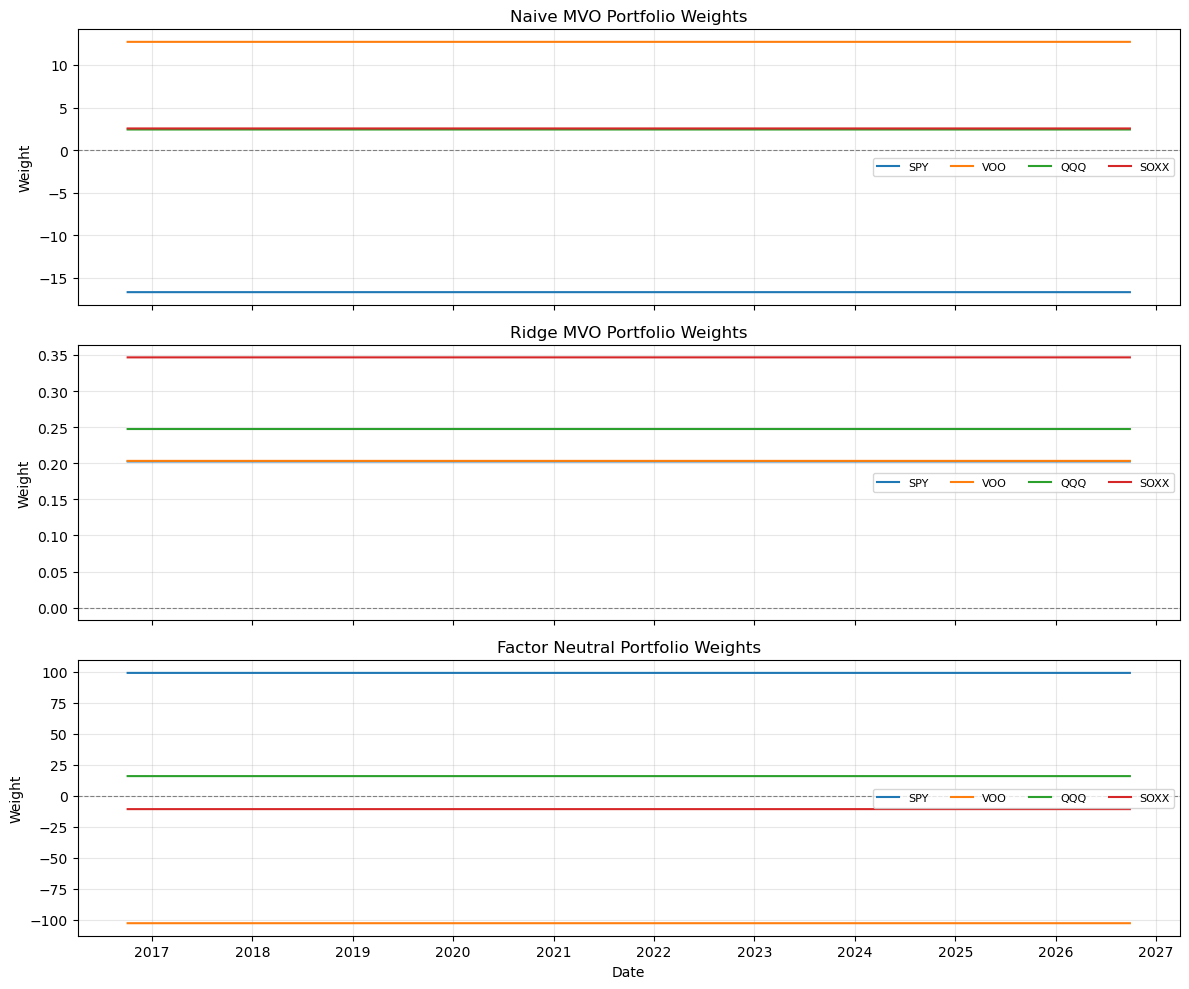

In [77]:
# 26. PORTFOLIO WEIGHTS
# =========================

# Display the portfolio weights
print("Portfolio weights:")
display(strategy_weights.round(4))

# Plot weights across the sample period
weights_over_time = pd.DataFrame(
    index=R.index
)

for strategy in strategy_weights.columns:
    for ticker in tickers:
        weights_over_time[
            f"{strategy} - {ticker}"
        ] = strategy_weights.loc[ticker, strategy]

# Plot each strategy separately
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 10),
    sharex=True
)

for ax, strategy in zip(
    axes,
    strategy_weights.columns
):
    
    for ticker in tickers:
        ax.plot(
            weights_over_time.index,
            weights_over_time[
                f"{strategy} - {ticker}"
            ],
            label=ticker,
            linewidth=1.5
        )
    
    ax.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=0.8
    )
    
    ax.set_title(f"{strategy} Portfolio Weights")
    ax.set_ylabel("Weight")
    ax.grid(alpha=0.3)
    ax.legend(
        ncol=4,
        fontsize=8
    )

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

In [83]:
# 27. SUMMARY TABLE
# =========================

# --------------------------------------------------
# 1. Prepare clean data
# --------------------------------------------------

# Two-factor model
F_two = returns[["MKT", "HML"]].copy()

# Risk-free daily rate
rf_daily = prices[rf_ticker] / 100 / trading_days

# Combine everything into one DataFrame
regression_data = pd.concat(
    [
        portfolio_returns,
        F_two,
        rf_daily.rename("RF")
    ],
    axis=1
)

# Replace infinite values with NaN
regression_data = regression_data.replace(
    [np.inf, -np.inf],
    np.nan
)

# Remove rows with missing values
regression_data = regression_data.dropna()

print(
    "Observations used in regression:",
    len(regression_data)
)


# --------------------------------------------------
# 2. Annualised portfolio return
# --------------------------------------------------

annualised_return = (
    portfolio_returns.mean()
    * trading_days
)


# --------------------------------------------------
# 3. Annualised portfolio volatility
# --------------------------------------------------

annualised_volatility = (
    portfolio_returns.std()
    * np.sqrt(trading_days)
)


# --------------------------------------------------
# 4. Two-factor regression
# --------------------------------------------------
#
# Rp - Rf =
# alpha + beta_MKT*MKT + beta_HML*HML + error
#

X = np.column_stack([
    np.ones(len(regression_data)),
    regression_data["MKT"].values,
    regression_data["HML"].values
])

regression_results = {}

for strategy in portfolio_returns.columns:

    # Excess portfolio return
    y = (
        regression_data[strategy]
        - regression_data["RF"]
    ).values

    # OLS regression
    coefficients = np.linalg.lstsq(
        X,
        y,
        rcond=None
    )[0]

    alpha_daily = coefficients[0]
    beta_mkt = coefficients[1]
    beta_hml = coefficients[2]

    # Regression residuals
    residuals = y - X @ coefficients

    # Degrees of freedom
    dof = len(y) - X.shape[1]

    # Residual variance
    residual_variance = (
        residuals @ residuals
    ) / dof

    # Variance-covariance matrix of coefficients
    XTX_inv = np.linalg.inv(X.T @ X)

    # Standard error of alpha
    alpha_se = np.sqrt(
        residual_variance * XTX_inv[0, 0]
    )

    # Alpha t-statistic
    alpha_tstat = (
        alpha_daily / alpha_se
    )

    regression_results[strategy] = {
        "Alpha": alpha_daily,
        "Beta MKT": beta_mkt,
        "Beta HML": beta_hml,
        "Alpha t-stat": alpha_tstat
    }


regression_results = pd.DataFrame(
    regression_results
).T


# --------------------------------------------------
# 5. Annualised alpha
# --------------------------------------------------

annualised_alpha = (
    regression_results["Alpha"]
    * trading_days
)


# --------------------------------------------------
# 6. Tracking Error
# --------------------------------------------------
#
# Benchmark = equal-weight portfolio
#
# TE² = (w - wb)' Σ (w - wb)
#

benchmark_weights = (
    np.ones(len(tickers))
    / len(tickers)
)

tracking_error = {}

for strategy in strategy_weights.columns:

    active_weights = (
        strategy_weights[strategy].values
        - benchmark_weights
    )

    TE_squared = (
        active_weights
        @ Sigma.values
        @ active_weights
    )

    tracking_error[strategy] = np.sqrt(
        TE_squared
    )

tracking_error = pd.Series(
    tracking_error
)


# --------------------------------------------------
# 7. CVaR
# --------------------------------------------------
#
# 95% CVaR = average loss in the worst 5%
# of observed daily portfolio returns.
#

confidence_level = 0.95

cvar = {}

for strategy in portfolio_returns.columns:

    strategy_returns = (
        portfolio_returns[strategy]
        .dropna()
    )

    var_threshold = strategy_returns.quantile(
        1 - confidence_level
    )

    worst_returns = strategy_returns[
        strategy_returns <= var_threshold
    ]

    cvar[strategy] = -worst_returns.mean()


cvar = pd.Series(cvar)


# --------------------------------------------------
# 8. Consolidated summary table
# --------------------------------------------------

summary = pd.DataFrame({

    "Annualised Return":
        annualised_return,

    "Annualised Volatility":
        annualised_volatility,

    "Alpha":
        annualised_alpha,

    "Beta MKT":
        regression_results["Beta MKT"],

    "Beta HML":
        regression_results["Beta HML"],

    "Tracking Error":
        tracking_error,

    "CVaR 95%":
        cvar,

    "Alpha t-stat":
        regression_results["Alpha t-stat"]

})


# --------------------------------------------------
# 9. Display final summary table
# --------------------------------------------------

print("Portfolio Strategy Comparison")

display(
    summary.style.format({
        "Annualised Return": "{:.2%}",
        "Annualised Volatility": "{:.2%}",
        "Alpha": "{:.2%}",
        "Beta MKT": "{:.3f}",
        "Beta HML": "{:.3f}",
        "Tracking Error": "{:.2%}",
        "CVaR 95%": "{:.2%}",
        "Alpha t-stat": "{:.3f}"
    })
)

Observations used in regression: 2508
Portfolio Strategy Comparison


,Annualised Return,Annualised Volatility,Alpha,Beta MKT,Beta HML,Tracking Error,CVaR 95%,Alpha t-stat
Naive MVO,77.20%,84.12%,353.66%,0.513,-3.987,67.19%,12.20%,11.940
Ridge MVO,23.69%,23.77%,184.20%,0.283,-0.836,2.22%,3.49%,21.647
Factor Neutral,-102.03%,206.17%,-545.49%,-0.747,-0.384,215.20%,29.45%,-5.630
